# ДЗ №5. TIGER-like архитектура для рекомендаций

Общая информация  

Дата выдачи: 25 мая 2026

Дедлайн: 10 июня 2026 23:59 MSK


В этом задании мы соберем упрощенный generative retrieval pipeline по мотивам [**TIGER**](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf):

1. Возьмем датасет **KION**.
2. Построим для айтемов **semantic ids** через **RQ-VAE**.
3. Поверх semantic ids обучим **tiger-like** next-token recommender.
4. Посчитаем метрики на **настоящих `item_id`**, а не на токенах semantic id.
5. Сравним результат с `MostPop` и `SASRec-like` baseline.
6. Отдельно проверим, что происходит, если semantic id обучаются **без уникализирующего suffix/id**, а затем декодируются обратно в item разными способами.

В отличие от классических retrieval-моделей, здесь модель не ранжирует весь каталог напрямую, а **генерирует код следующего айтема**. Поэтому в этом ДЗ важно аккуратно разделять:

- качество самих semantic ids;
- качество generative модели по semantic ids;
- качество итоговых рекомендаций после обратного декодинга в реальные `item_id`.


В этом задании следующая разбалловка:

1. Обучение и анализ semantic ids через `RQ-VAE` - **3 балла**
2. Обучение `tiger-like` next-token модели - **3 балла**
3. Сравнение с `MostPop` и `SASRec-like` - **2 балла**
4. Эксперимент с неуникальными semantic ids и разными стратегиями декодинга - **2 балла**

Соответственно, максимум можно набрать **10 баллов**.


## Короткая теория

### 1. Semantic IDs

Проблема обычных `item_id` в том, что они, как правило, **не несут семантики**: два похожих фильма имеют совершенно независимые идентификаторы.  
Идея semantic ids состоит в том, чтобы сопоставить каждому айтему **короткую дискретную последовательность токенов**, где близкие по смыслу айтемы имеют похожие коды.

Для этого удобно взять фиксированные item-embeddings по контенту и затем **квантовать** их через `RQ-VAE`:

- encoder переводит эмбеддинг в другое скрытое представление;
- residual quantization по нескольким codebook-уровням превращает в последовательность дискретных кодов;
- decoder пытается восстановить исходный embedding;
- дополнительные регуляризаторы позволяют контролировать загрузку codebook-ов, коллизии и энтропию.

### 2. TIGER-like generative retrieval

В статье TIGER recommendation рассматривается как **autoregressive generation** semantic id следующего айтема.  
История пользователя кодируется как последовательность токенов прошлых semantic ids, а модель предсказывает токены следующего айтема.

Упрощенно это выглядит так:

- у айтема есть semantic id, например `[c1, c2, c3, c4]`;
- история пользователя превращается в длинную token-sequence;
- decoder-only Transformer предсказывает следующий токен;
- после генерации semantic id он декодируется обратно в реальный `item_id`.

### 3. Зачем нужен уникализирующий suffix

Если несколько айтемов попадают в один и тот же semantic bucket, возникает **коллизия**.  
Один способ справиться с этим - добавить к semantic id дополнительный уникализирующий suffix.  
Другой путь - оставить id чисто семантическим, а потом восстанавливать `item_id` через отдельный mapping внутри bucket-а. Именно это вы исследуете в последней части ДЗ.


[Ссылка](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf) на работу по Semantic-ids и TIGER: 




In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn torch tqdm sentencepiece

In [2]:
import math
import random
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [21]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Загрузка данных

Работаем с KION-датасетом из соревнования:

https://ods.ai/competitions/competition-recsys-21/data

Нужны файлы:

- `interactions.csv`
- `items.csv`
- `users.csv`

Ноутбук ищет их рядом с собой, уровнем выше или на два уровня выше.


In [22]:
def find_file(candidates: List[str]) -> Optional[Path]:
    search_roots = [Path("."), Path(".."), Path("../.."), Path("/mnt/data"), Path("/content/drive/MyDrive")]
    for root in search_roots:
        for name in candidates:
            path = root / name
            if path.exists():
                return path.resolve()
    return None


interactions_path = find_file(["interactions.csv", "kion_interactions.csv"])
items_path = find_file(["items.csv", "kion_items.csv"])
users_path = find_file(["users.csv", "kion_users.csv"])

print("interactions_path =", interactions_path)
print("items_path        =", items_path)
print("users_path        =", users_path)


interactions_path = /content/drive/MyDrive/interactions.csv
items_path        = /content/drive/MyDrive/items.csv
users_path        = /content/drive/MyDrive/users.csv


In [23]:
assert interactions_path is not None, "Не найден interactions.csv"
assert items_path is not None, "Не найден items.csv"
assert users_path is not None, "Не найден users.csv"

interactions = pd.read_csv(interactions_path)
items = pd.read_csv(items_path)
users = pd.read_csv(users_path)

print(interactions.shape, items.shape, users.shape)
interactions.head()


(5476251, 5) (15963, 14) (840197, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


## 1. Подготовка выборки

Чтобы не делать ДЗ неподъемным, возьмем **сэмпл активных пользователей и популярных айтемов**.  
При желании вы можете изменить размеры выборки, но в отчете обязательно укажите, какой сэмпл использовали.


In [24]:
SAMPLE_USERS = 15000
SAMPLE_ITEMS = 20000
MIN_USER_INTERACTIONS = 5
MAX_SEQ_LEN = 50
TOP_K = 10


TARGET_COL = "item_id"
USER_COL = "user_id"
TIME_COL = "last_watch_dt" if "last_watch_dt" in interactions.columns else "watched_pct"


In [25]:
interactions = interactions.copy()

if "last_watch_dt" in interactions.columns:
    interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])
    sort_cols = [USER_COL, "last_watch_dt"]
else:
    sort_cols = [USER_COL]

if "total_dur" in interactions.columns:
    interactions["total_dur"] = interactions["total_dur"].fillna(0)

user_activity = interactions[USER_COL].value_counts()
item_popularity = interactions[TARGET_COL].value_counts()

selected_users = user_activity.head(SAMPLE_USERS).index
selected_items = item_popularity.head(SAMPLE_ITEMS).index

df = interactions[
    interactions[USER_COL].isin(selected_users) &
    interactions[TARGET_COL].isin(selected_items)
].copy()

df = df.sort_values(sort_cols).reset_index(drop=True)
df = df[df.groupby(USER_COL)[TARGET_COL].transform("size") >= MIN_USER_INTERACTIONS].copy()

print(df.shape)
df.head()


(995585, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,2,7571,2021-05-20,6151,100.0
1,2,11577,2021-05-21,4974,98.0
2,2,16166,2021-05-21,5980,95.0
3,2,8936,2021-05-29,18,1.0
4,2,4436,2021-05-29,2618,30.0


Сделайте split по пользователям в стиле leave-last-out:

- `train`: вся история кроме двух последних событий пользователя;
- `valid`: предпоследний айтем;
- `test`: последний айтем.

Если хотите, можете использовать другой аккуратный temporal split, но тогда явно опишите его в отчете.


In [26]:
def leave_last_two_out(data: pd.DataFrame, user_col: str, item_col: str, sort_cols: List[str]):
    data = data.sort_values(sort_cols).copy()
    data["_row_num"] = data.groupby(user_col).cumcount()
    data["_user_len"] = data.groupby(user_col)[item_col].transform("size")

    train = data[data["_row_num"] < data["_user_len"] - 2].copy()
    valid = data[data["_row_num"] == data["_user_len"] - 2].copy()
    test = data[data["_row_num"] == data["_user_len"] - 1].copy()

    return (
        train.drop(columns=["_row_num", "_user_len"]),
        valid.drop(columns=["_row_num", "_user_len"]),
        test.drop(columns=["_row_num", "_user_len"]),
    )


train_df, valid_df, test_df = leave_last_two_out(df, USER_COL, TARGET_COL, sort_cols)

print(train_df.shape, valid_df.shape, test_df.shape)


(965585, 5) (15000, 5) (15000, 5)


In [27]:
train_sequences = (
    train_df
    .sort_values(sort_cols)
    .groupby(USER_COL)[TARGET_COL]
    .apply(list)
    .to_dict()
)

valid_targets = dict(zip(valid_df[USER_COL], valid_df[TARGET_COL]))
test_targets = dict(zip(test_df[USER_COL], test_df[TARGET_COL]))

eval_users = sorted(set(test_targets) & set(train_sequences))
len(eval_users)

15000

## 2. Метрики

Мы сравниваем модели уже на **реальных item_id**.  
Реализуйте (или переиспользуйте реализации из предыдущих ДЗ) как минимум:

- `Recall@K`
- `NDCG@K`
- `MRR@K`

Можно дополнительно посчитать `HitRate@K`, `Coverage@K`, `Novelty@K`.


In [ ]:
def recall_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    users = [u for u in target if u in recs]
    if not users:
        return 0.0
    hits = 0
    for u in users:
        if target[u] in recs[u][:k]:
            hits += 1
    return hits / len(users)


def ndcg_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    users = [u for u in target if u in recs]
    if not users:
        return 0.0
    total = 0.0
    for u in users:
        top = recs[u][:k]
        if target[u] in top:
            rank = top.index(target[u]) + 1  # позиция с 1
            total += 1.0 / math.log2(rank + 1)
    return total / len(users)


def mrr_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    users = [u for u in target if u in recs]
    if not users:
        return 0.0
    total = 0.0
    for u in users:
        top = recs[u][:k]
        if target[u] in top:
            rank = top.index(target[u]) + 1
            total += 1.0 / rank
    return total / len(users)


def hit_rate_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    return recall_at_k(recs, target, k)



def coverage_at_k(recs: Dict[int, List[int]], n_items: int, k: int = 10) -> float:
    recommended = set()
    for u, items_list in recs.items():
        recommended.update(items_list[:k])
    if n_items <= 0:
        return 0.0
    return len(recommended) / n_items


def evaluate_recommendations(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> pd.DataFrame:
    return pd.DataFrame(
        {
            f"Recall@{k}": [recall_at_k(recs, target, k)],
            f"NDCG@{k}": [ndcg_at_k(recs, target, k)],
            f"MRR@{k}": [mrr_at_k(recs, target, k)],
        },
        index=["score"],
    )



## I. Semantic IDs через RQ-VAE (3 балла)

В этой части нужно:

1. Построить фиксированные item-embeddings по метаданным айтемов.
2. Обучить `RQ-VAE`, получив многотокенный semantic id.
3. Посчитать и визуализировать метрики качества semantic ids.

Обязательно покажите графики обучения хотя бы по:

- reconstruction loss;
- доле коллизий;
- энтропии использования кодов;
- average bucket size или effective codebook usage.

Дополнительно приветствуются:

- доля неиспользуемых кодов;

Реализацию вы можете взять отсюда [https://github.com/EdoardoBotta/RQ-VAE-Recommender](https://github.com/EdoardoBotta/RQ-VAE-Recommender)


Для простоты можно собрать content features из `title`, `genres`, `countries`, `release_year`, других доступных полей.  
Необязательно делать сильный content encoder: в этой работе главное не качество текстовой модели, а корректный пайплайн `semantic ids -> generative retrieval`.

Ниже используется TF-IDF, но вы можете заменить эмбеддер на любую хорошую языковую модель


In [29]:
def split_tokens(x) -> List[str]:
    if pd.isna(x):
        return []
    text = str(x)
    for sep in [",", "|", "/"]:
        if sep in text:
            return [part.strip() for part in text.split(sep) if part.strip()]
    return [text.strip()] if text.strip() else []


items_work = items[items[TARGET_COL].isin(pd.Index(df[TARGET_COL].unique()))].copy()
items_work["title"] = items_work.get("title", pd.Series("", index=items_work.index)).fillna("")
items_work["genres_text"] = items_work.get("genres", pd.Series("", index=items_work.index)).fillna("")
items_work["countries_text"] = items_work.get("countries", pd.Series("", index=items_work.index)).fillna("")
items_work["release_year_num"] = pd.to_numeric(
    items_work.get("release_year", pd.Series(np.nan, index=items_work.index)),
    errors="coerce",
).fillna(0)

items_work["content_text"] = (
    items_work["title"].astype(str) + " " +
    items_work["genres_text"].astype(str) + " " +
    items_work["countries_text"].astype(str)
)

items_work = items_work.drop_duplicates(subset=[TARGET_COL]).reset_index(drop=True)
items_work.head()


,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,genres_text,countries_text,release_year_num,content_text
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...","драмы, зарубежные, детективы, мелодрамы",Испания,2002.0,"Поговори с ней драмы, зарубежные, детективы, м..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...","зарубежные, приключения, комедии",США,2014.0,"Голые перцы зарубежные, приключения, комедии США"
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...","криминал, зарубежные, триллеры, боевики, комедии",Канада,2011.0,"Тактическая сила криминал, зарубежные, триллер..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...","драмы, зарубежные, мелодрамы",Великобритания,2015.0,"45 лет драмы, зарубежные, мелодрамы Великобрит..."
4,1468,film,Марья-искусница,NaN,1960.0,"фильмы, сказки, приключения, советские, семейн...",СССР,NaN,6.0,NaN,Александр Роу,"Александр Баранов, Александр Хвыля, Анатолий К...",Два прославленных советских сказочника – писат...,"Марья-искусница, 1960, СССР, преодоление, труд...","фильмы, сказки, приключения, советские, семейн...",СССР,1960.0,"Марья-искусница фильмы, сказки, приключения, с..."


In [30]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
text_features = vectorizer.fit_transform(items_work["content_text"])

svd = TruncatedSVD(n_components=128, random_state=RANDOM_STATE)
text_dense = svd.fit_transform(text_features)

num_features = items_work[["release_year_num"]].to_numpy(dtype=np.float32)
num_features = StandardScaler().fit_transform(num_features)

item_content_matrix = np.concatenate([text_dense, num_features], axis=1).astype(np.float32)
item_ids = items_work[TARGET_COL].tolist()

print(item_content_matrix.shape)


(13929, 129)


In [ ]:
@dataclass
class RQVAEConfig:
    input_dim: int
    hidden_dim: int = 256
    latent_dim: int = 64
    num_codebooks: int = 4
    codebook_size: int = 64
    commitment_weight: float = 0.25
    entropy_weight: float = 0.0


class VectorQuantizer(nn.Module):
    """Один codebook-уровень residual quantization."""

    def __init__(self, codebook_size: int, latent_dim: int):
        super().__init__()
        self.codebook_size = codebook_size
        self.latent_dim = latent_dim
        self.embedding = nn.Embedding(codebook_size, latent_dim)
        nn.init.normal_(self.embedding.weight, mean=0.0, std=latent_dim ** -0.5)

    def forward(self, residual: torch.Tensor):
        codebook = self.embedding.weight  # (K, D)
        dist = (
            residual.pow(2).sum(dim=1, keepdim=True)
            - 2 * residual @ codebook.t()
            + codebook.pow(2).sum(dim=1).unsqueeze(0)
        )  # (B, K)
        indices = torch.argmin(dist, dim=1)  # (B,)
        quantized = self.embedding(indices)  # (B, D)
        return quantized, indices


class RQVAE(nn.Module):
    def __init__(self, config: RQVAEConfig):
        super().__init__()
        self.config = config

        self.encoder = nn.Sequential(
            nn.Linear(config.input_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.latent_dim),
        )

        self.quantizers = nn.ModuleList(
            [
                VectorQuantizer(config.codebook_size, config.latent_dim)
                for _ in range(config.num_codebooks)
            ]
        )

        self.decoder = nn.Sequential(
            nn.Linear(config.latent_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.input_dim),
        )

    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def quantize(self, z_e: torch.Tensor):
        """Residual quantization: на каждом уровне квантуем остаток.
        """
        residual = z_e
        z_q = torch.zeros_like(z_e)
        indices_list = []
        codebook_loss = torch.tensor(0.0, device=z_e.device)
        commitment_loss = torch.tensor(0.0, device=z_e.device)
        entropy_loss = torch.tensor(0.0, device=z_e.device)

        for quantizer in self.quantizers:
            quantized, indices = quantizer(residual)

            codebook_loss = codebook_loss + F.mse_loss(quantized, residual.detach())
            commitment_loss = commitment_loss + F.mse_loss(quantized.detach(), residual)

            if self.config.entropy_weight > 0:
                onehot = F.one_hot(indices, self.config.codebook_size).float()
                probs = onehot.mean(dim=0)
                probs = probs + 1e-9
                neg_entropy = (probs * probs.log()).sum()
                entropy_loss = entropy_loss + neg_entropy

            z_q = z_q + quantized
            residual = residual - quantized.detach()
            indices_list.append(indices)

        z_q = z_e + (z_q - z_e).detach()

        indices = torch.stack(indices_list, dim=1)  # (B, num_codebooks)
        return z_q, indices, codebook_loss, commitment_loss, entropy_loss

    def decode(self, z_q: torch.Tensor):
        return self.decoder(z_q)

    def forward(self, x: torch.Tensor):
        z_e = self.encode(x)
        z_q, indices, codebook_loss, commitment_loss, entropy_loss = self.quantize(z_e)
        x_hat = self.decode(z_q)

        recon_loss = F.mse_loss(x_hat, x)
        loss = (
            recon_loss
            + codebook_loss
            + self.config.commitment_weight * commitment_loss
            + self.config.entropy_weight * entropy_loss
        )

        return {
            "x_hat": x_hat,
            "z_e": z_e,
            "z_q": z_q,
            "indices": indices,
            "loss": loss,
            "recon_loss": recon_loss,
            "codebook_loss": codebook_loss,
            "commitment_loss": codebook_loss + commitment_loss,
            "entropy_loss": entropy_loss,
        }

    @torch.no_grad()
    def get_codes(self, x: torch.Tensor) -> torch.Tensor:
        z_e = self.encode(x)
        _, indices, _, _, _ = self.quantize(z_e)
        return indices

In [42]:
@torch.no_grad()
def residual_kmeans_init(
    model: RQVAE,
    data_tensor: torch.Tensor,
    batch_size: int = 4096,
    seed: int = RANDOM_STATE,
):
    model.eval()
    device = next(model.parameters()).device

    latent_chunks = []

    for start in range(0, len(data_tensor), batch_size):
        batch = data_tensor[start:start + batch_size].to(device)
        z = model.encode(batch)
        latent_chunks.append(z.cpu())

    residual = torch.cat(latent_chunks, dim=0).numpy()

    print("Residual KMeans init started")

    for level, quantizer in enumerate(model.quantizers):
        print(f"Level {level + 1}/{len(model.quantizers)} (K={quantizer.codebook_size})")

        kmeans = MiniBatchKMeans(
            n_clusters=quantizer.codebook_size,
            batch_size=4096,
            n_init=100,
            random_state=seed,
        )

        assignments = kmeans.fit_predict(residual)

        centroids = torch.tensor(
            kmeans.cluster_centers_,
            dtype=torch.float32,
            device=device,
        )

        quantizer.embedding.weight.data.copy_(centroids)

        quantized = centroids[torch.tensor(assignments, device=device)].cpu().numpy()
        residual = residual - quantized

        mse = np.mean(residual ** 2)

        print(f"  residual mse after level {level + 1}: {mse:.6f}")

    print("Residual KMeans init finished")

In [43]:
def semantic_collision_rate(codes: np.ndarray) -> float:
    unique_codes = {tuple(row.tolist()) for row in codes}
    return 1.0 - len(unique_codes) / len(codes)


def average_bucket_size(codes: np.ndarray) -> float:
    buckets = Counter(map(tuple, codes.tolist()))
    return float(np.mean(list(buckets.values())))


def codebook_entropy(codes_2d: np.ndarray, codebook_size: int) -> List[float]:
    entropies = []
    for level in range(codes_2d.shape[1]):
        counts = np.bincount(codes_2d[:, level], minlength=codebook_size).astype(np.float64)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(float(-(probs * np.log(probs + 1e-12)).sum()))
    return entropies


In [44]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [ ]:
rq_config = RQVAEConfig(input_dim=item_content_matrix.shape[1])
rqvae = RQVAE(rq_config).to(DEVICE)

content_tensor = torch.tensor(item_content_matrix, dtype=torch.float32)
residual_kmeans_init(rqvae, content_tensor) #!!!
rq_dataset = torch.utils.data.TensorDataset(content_tensor)
rq_loader = torch.utils.data.DataLoader(rq_dataset, batch_size=256, shuffle=True)

Residual KMeans init started
Level 1/4 (K=64)
  residual mse after level 1: 0.000011
Level 2/4 (K=64)
  residual mse after level 2: 0.000006
Level 3/4 (K=64)
  residual mse after level 3: 0.000004
Level 4/4 (K=64)
  residual mse after level 4: 0.000004
Residual KMeans init finished


In [ ]:
all_content = content_tensor.to(DEVICE)

RQ_EPOCHS = 150
optimizer = torch.optim.Adam(rqvae.parameters(), lr=1e-3)

rq_history = {
    "total_loss": [],
    "recon_loss": [],
    "commitment_loss": [],
    "collision_rate": [],
    "avg_bucket_size": [],
    "mean_entropy": [],
    "entropy_per_codebook": [],
    "unused_codes": [],
}

for epoch in tqdm(range(RQ_EPOCHS), desc="RQ-VAE training"):
    rqvae.train()
    epoch_total, epoch_recon, epoch_commit, n_batches = 0.0, 0.0, 0.0, 0
    
    if epoch < 50:
        for q in rqvae.quantizers:
            q.embedding.weight.requires_grad_(False)
    else:
        for q in rqvae.quantizers:
            q.embedding.weight.requires_grad_(True)
            
    for (batch_x,) in rq_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        out = rqvae(batch_x)
        out["loss"].backward()
        optimizer.step()

        epoch_total += out["loss"].item()
        epoch_recon += out["recon_loss"].item()
        epoch_commit += out["commitment_loss"].item()
        n_batches += 1

    rqvae.eval()
    with torch.no_grad():
        codes = rqvae.get_codes(all_content).cpu().numpy()  # (N, num_codebooks)

    coll = semantic_collision_rate(codes)
    bucket = average_bucket_size(codes)
    entropies = codebook_entropy(codes, rq_config.codebook_size)

    unused = []
    for level in range(codes.shape[1]):
        used = len(np.unique(codes[:, level]))
        unused.append(1.0 - used / rq_config.codebook_size)

    rq_history["total_loss"].append(epoch_total / n_batches)
    rq_history["recon_loss"].append(epoch_recon / n_batches)
    rq_history["commitment_loss"].append(epoch_commit / n_batches)
    rq_history["collision_rate"].append(coll)
    rq_history["avg_bucket_size"].append(bucket)
    rq_history["mean_entropy"].append(float(np.mean(entropies)))
    rq_history["entropy_per_codebook"].append(entropies)
    rq_history["unused_codes"].append(float(np.mean(unused)))

print("Финальный collision rate:", rq_history["collision_rate"][-1])
print("Финальный recon loss:", rq_history["recon_loss"][-1])
print("Финальный avg bucket size:", rq_history["avg_bucket_size"][-1])

RQ-VAE training:   0%|          | 0/150 [00:00<?, ?it/s]

Финальный collision rate: 0.3660707875655108
Финальный recon loss: 0.0008040211290459741
Финальный avg bucket size: 1.5774631936579842


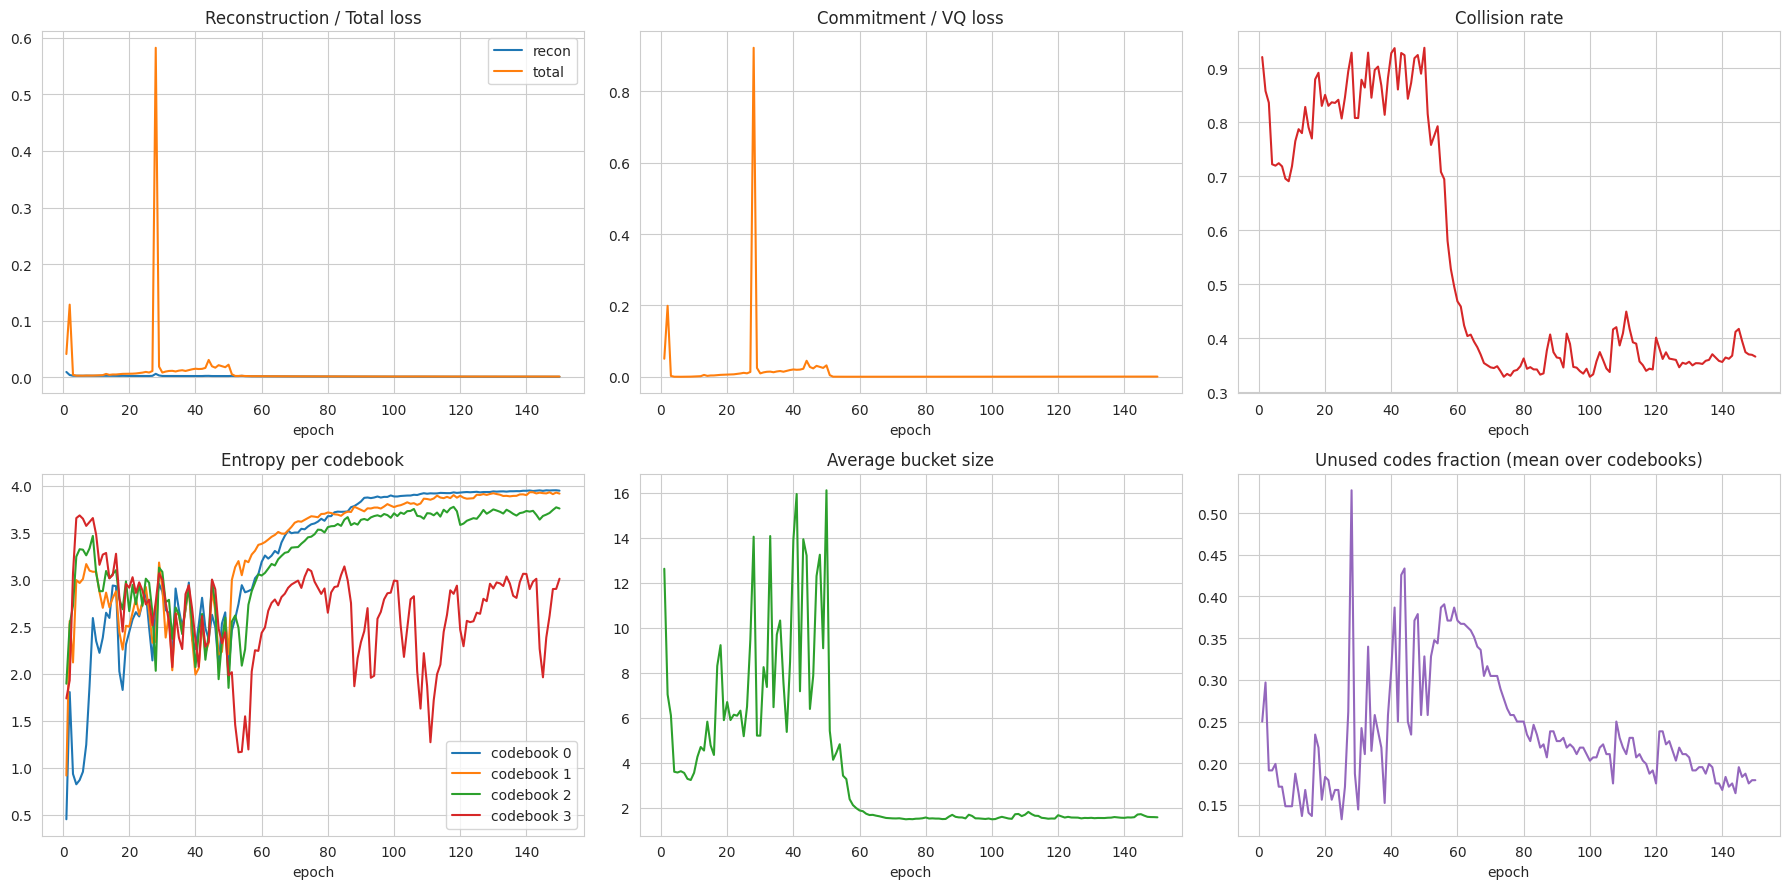

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

epochs_axis = range(1, len(rq_history["total_loss"]) + 1)

axes[0, 0].plot(epochs_axis, rq_history["recon_loss"], label="recon")
axes[0, 0].plot(epochs_axis, rq_history["total_loss"], label="total")
axes[0, 0].set_title("Reconstruction / Total loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend()

axes[0, 1].plot(epochs_axis, rq_history["commitment_loss"], color="tab:orange")
axes[0, 1].set_title("Commitment / VQ loss")
axes[0, 1].set_xlabel("epoch")

axes[0, 2].plot(epochs_axis, rq_history["collision_rate"], color="tab:red")
axes[0, 2].set_title("Collision rate")
axes[0, 2].set_xlabel("epoch")

# энтропия по каждому codebook-уровню
entropy_arr = np.array(rq_history["entropy_per_codebook"])  # (epochs, num_codebooks)
for level in range(entropy_arr.shape[1]):
    axes[1, 0].plot(epochs_axis, entropy_arr[:, level], label=f"codebook {level}")
axes[1, 0].set_title("Entropy per codebook")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend()

axes[1, 1].plot(epochs_axis, rq_history["avg_bucket_size"], color="tab:green")
axes[1, 1].set_title("Average bucket size")
axes[1, 1].set_xlabel("epoch")

axes[1, 2].plot(epochs_axis, rq_history["unused_codes"], color="tab:purple")
axes[1, 2].set_title("Unused codes fraction (mean over codebooks)")
axes[1, 2].set_xlabel("epoch")

plt.tight_layout()
plt.show()

Добавил KMeans initialization (До этого коллизия была 99%)

>При итоговых 100 эпохах:

Проверил результаты  отсутствия градиента для codebooks на первых 10 эпохах:

        Финальный collision rate: 0.394
        Финальный recon loss: 0.00092
        Финальный avg bucket size: 1.651


Проверил результаты  отсутствия градиента для codebooks на первых 25 эпохах:

        Финальный collision rate: 0.351
        Финальный recon loss: 0.001
        Финальный avg bucket size: 1.541

При отсутствии градиента на 25 эпохах результат получше (остаивл его)

(Это результаты при другой случайной инициализации - добавил seeds в KMeans потом)

In [ ]:
rqvae.eval()
with torch.no_grad():
    final_codes = rqvae.get_codes(all_content).cpu().numpy()  # (N, num_codebooks)

semantic_tokens = [tuple(int(c) for c in row) for row in final_codes]
bucket_counter: Dict[Tuple[int, ...], int] = defaultdict(int)
semantic_tokens_unique = []
for tok in semantic_tokens:
    suffix = bucket_counter[tok]
    bucket_counter[tok] += 1
    semantic_tokens_unique.append(tok + (suffix,))

semantic_df = pd.DataFrame(
    {
        "item_id": item_ids,
        "semantic_tokens": semantic_tokens,
        "semantic_tokens_unique": semantic_tokens_unique,
    }
)

item_to_sid = dict(zip(semantic_df["item_id"], semantic_df["semantic_tokens"]))
item_to_sid_unique = dict(zip(semantic_df["item_id"], semantic_df["semantic_tokens_unique"]))

# bucket (semantic id без suffix) -> список item_id
sid_to_items: Dict[Tuple[int, ...], List[int]] = defaultdict(list)
for iid, tok in zip(semantic_df["item_id"], semantic_df["semantic_tokens"]):
    sid_to_items[tok].append(iid)

max_suffix = max(len(v) for v in sid_to_items.values())
print("Число айтемов:", len(semantic_df))
print("Число уникальных semantic buckets:", len(sid_to_items))
print("Максимальный размер уникализатора (suffix):", max_suffix)
semantic_df.head()

Число айтемов: 13929
Число уникальных semantic buckets: 8830
Максимальный размер уникализатора (suffix): 57


,item_id,semantic_tokens,semantic_tokens_unique
0,10711,"(25, 30, 61, 1)","(25, 30, 61, 1, 0)"
1,2508,"(61, 47, 27, 23)","(61, 47, 27, 23, 0)"
2,10716,"(19, 30, 52, 34)","(19, 30, 52, 34, 0)"
3,7868,"(25, 38, 7, 35)","(25, 38, 7, 35, 0)"
4,1468,"(51, 40, 14, 22)","(51, 40, 14, 22, 0)"


Сформируйте итоговую таблицу по semantic ids. Например:

- число уникальных semantic ids;
- collision rate;
- средняя мощность bucket-а;
- средняя энтропия по codebook-уровням;
- число неиспользованных кодов по уровням.


In [ ]:
n_unique = len({tuple(r) for r in final_codes})
coll_rate = semantic_collision_rate(final_codes)
avg_bucket = average_bucket_size(final_codes)
entropies_final = codebook_entropy(final_codes, rq_config.codebook_size)

unused_per_level = []
for level in range(final_codes.shape[1]):
    used = len(np.unique(final_codes[:, level]))
    unused_per_level.append(rq_config.codebook_size - used)

semantic_metrics_table = pd.DataFrame(
    {
        "value": [
            len(final_codes),
            n_unique,
            coll_rate,
            avg_bucket,
            float(np.mean(entropies_final)),
            float(np.sum(unused_per_level)),
        ]
    },
    index=[
        "num_items",
        "num_unique_semantic_ids",
        "collision_rate",
        "avg_bucket_size",
        "mean_entropy_over_codebooks",
        "total_unused_codes",
    ],
)

per_level_table = pd.DataFrame(
    {
        "entropy": entropies_final,
        "unused_codes": unused_per_level,
    },
    index=[f"codebook_{i}" for i in range(final_codes.shape[1])],
)

print(per_level_table)
semantic_metrics_table

             entropy  unused_codes
codebook_0  3.948806             1
codebook_1  3.917714             0
codebook_2  3.759150            10
codebook_3  3.012312            35


,value
num_items,13929.000000
num_unique_semantic_ids,8830.000000
collision_rate,0.366071
avg_bucket_size,1.577463
mean_entropy_over_codebooks,3.659496
total_unused_codes,46.000000


В целом видно что на 1 уровне 1  неиспользуемый codebook, , на втором уровне вообще 0. Что немного странно, так как то, что  количество неиспользованных codebooks растёт с увеличением уровня - нормально и естественно. 

По результатам этого пункта у вас должна получиться таблица: item_id -> semantic_id, причем должны быть все айтемы помапплены. Еще раз убедитесь, что вы понимаете проблему коллизий. Если RQ-VAE кодирует 3 кодбука, то s-id = 3 кода + 1 уникализирующий код. Вместе с уникализириющим кодом s-id становится полноценным (однозначным) идентификатором конкретного айтема. Без этого кода вы теряете часть информации.

Далее вы можете обучать модель как с этим уникализирующим кодом, так и без него. Однако здесь у вас будет возникать разница:
1) если TIGER работает без уникализирующего id в конце, то вам надо дополнительно сделать процедуру декодинга. Тогда TIGER работает только на семантике, а рекомендацией из semantic в конкретные айди занимаетесь уже вы сами. TIGER также теряет часть информации, но с другой стороны фокусируется только на контентной составляющей.
2) если TIGER работает с уникализирующим id в конце, то подразумевается, что модель будет рекомендовать вам полноценные sid, эквивалентные item_id (с маппингом 1 к 1). В этом случае модель будет уже не только на семантической информации, но и в том числе ей надо будет запоминать конкретные айдишники (это более сложная задача)

В последнем пункте (если вы хотите получить максимальный балл) вам в любом случае надо будет сравнить оба подхода, поэтому выбранный тут подход остается на ваше усмотрение


## II. Tiger-like next-token prediction (3 балла)

Теперь построим `tiger-like` модель поверх semantic ids.

Нужно:

1. Преобразовать пользовательские истории в последовательности semantic-токенов.
2. Обучить causal next-token модель (например, GPT2 from scratch), можно не очень большую (4/4/256, например)
3. Сгенерировать рекомендации.
4. Декодировать сгенерированные semantic ids обратно в `item_id`.
5. Посчитать финальные метрики на настоящих айтемах.


Важно: качество оценивается не по совпадению токенов само по себе, а по тому, удается ли после декодинга получить релевантные **реальные** `item_id`.


In [ ]:
USE_UNIQUE_SUFFIX = True
item_to_tokens_raw = item_to_sid_unique          # с суффиксом → 1:1 маппинг
NUM_LEVELS = rq_config.num_codebooks + 1         # codebooks + 1 уровень суффикса

SPECIAL_TOKENS = {
    "PAD": 0,
    "BOS": 1,
    "EOS": 2,
    "SEP": 3,
}

n_special = len(SPECIAL_TOKENS)
level_offsets = []
offset = n_special
for level in range(NUM_LEVELS):
    level_offsets.append(offset)
    if level < rq_config.num_codebooks:
        offset += rq_config.codebook_size
    else:
        offset += max(len(v) for v in sid_to_items.values())  

VOCAB_SIZE = offset

print(f"NUM_LEVELS:  {NUM_LEVELS}")
print(f"VOCAB_SIZE:  {VOCAB_SIZE}")
print(f"level_offsets: {level_offsets}")

NUM_LEVELS:  5
VOCAB_SIZE:  317
level_offsets: [4, 68, 132, 196, 260]


In [ ]:
def tokens_to_vocab_ids(tokens: Tuple[int, ...]) -> List[int]:
    """Кортеж кодов айтема (включая суффикс) → глобальные id словаря."""
    assert len(tokens) == NUM_LEVELS, (
        f"Ожидается {NUM_LEVELS} кодов, получено {len(tokens)}"
    )
    return [level_offsets[level] + int(code) for level, code in enumerate(tokens)]



item_to_token_ids: Dict[int, List[int]] = {
    iid: tokens_to_vocab_ids(tok)
    for iid, tok in item_to_tokens_raw.items()
}

full_sid_to_item: Dict[Tuple[int, ...], int] = {
    tok: iid for iid, tok in item_to_tokens_raw.items()
}


def vocab_ids_to_codes(vocab_ids: List[int]) -> Optional[Tuple[int, ...]]:
    """Глобальные vocab ids → кортеж исходных кодов. None если невалидно."""
    if len(vocab_ids) != NUM_LEVELS:
        return None
    codes = []
    for level, vid in enumerate(vocab_ids):
        base = level_offsets[level]
        code = vid - base
        if level < rq_config.num_codebooks:
            if code < 0 or code >= rq_config.codebook_size:
                return None
        else:
            max_suffix = max(len(v) for v in sid_to_items.values())
            if code < 0 or code >= max_suffix:
                return None
        codes.append(code)
    return tuple(codes)

In [111]:
def build_token_sequence(item_history: List[int]) -> List[int]:
    """История айтемов → плоская последовательность vocab ids с SEP между айтемами."""
    seq = []
    for iid in item_history:
        if iid in item_to_token_ids:
            seq.extend(item_to_token_ids[iid])
            seq.append(SPECIAL_TOKENS["SEP"])
    return seq


MAX_ITEMS_IN_HISTORY = 20


def make_samples(target_dict: Dict[int, int]) -> List[Dict[str, torch.Tensor]]:
    """
    Строит обучающие сэмплы для teacher-forcing.
    Вход:  BOS + история + токены таргета
    Лосс:  только на токенах таргета + EOS
    """
    samples = []
    for user_id, target_item in target_dict.items():
        if user_id not in train_sequences:
            continue
        if target_item not in item_to_token_ids:
            continue

        history = train_sequences[user_id][-MAX_ITEMS_IN_HISTORY:]
        history_tokens = build_token_sequence(history)
        if not history_tokens:
            continue

        target_tokens = item_to_token_ids[target_item]

        input_seq  = [SPECIAL_TOKENS["BOS"]] + history_tokens + target_tokens + [SPECIAL_TOKENS["EOS"]]
        prefix_len = 1 + len(history_tokens)
        loss_mask  = [0] * prefix_len + [1] * (len(target_tokens) + 1)  # +1 за EOS

        samples.append({
            "input_ids": torch.tensor(input_seq, dtype=torch.long),
            "loss_mask": torch.tensor(loss_mask, dtype=torch.float),
            "user_id":   user_id,
        })
    return samples


train_samples = make_samples(valid_targets)
print("train samples (TIGER):", len(train_samples))

train samples (TIGER): 15000


In [112]:
class TigerSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, samples: List[Dict[str, torch.Tensor]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_batch(batch):
    max_len = max(len(s["input_ids"]) for s in batch)
    pad_id = SPECIAL_TOKENS["PAD"]

    input_ids = torch.full((len(batch), max_len), pad_id, dtype=torch.long)
    loss_mask = torch.zeros((len(batch), max_len), dtype=torch.float)
    attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)
    user_ids = []

    for i, s in enumerate(batch):
        L = len(s["input_ids"])
        input_ids[i, :L] = s["input_ids"]
        loss_mask[i, :L] = s["loss_mask"]
        attention_mask[i, :L] = 1
        user_ids.append(s["user_id"])

    return {
        "input_ids": input_ids,
        "loss_mask": loss_mask,
        "attention_mask": attention_mask,
        "user_ids": user_ids,
    }

In [57]:
class TigerLikeModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 192,
        n_heads: int = 4,
        n_layers: int = 3,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=SPECIAL_TOKENS["PAD"])
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None):
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        x = self.dropout(x)

        # causal маска (decoder-only): запрещаем смотреть в будущее
        causal_mask = torch.triu(
            torch.ones(T, T, device=input_ids.device, dtype=torch.bool), diagonal=1
        )

        # padding mask: True там, где PAD (игнорируем)
        if attention_mask is not None:
            key_padding_mask = attention_mask == 0
        else:
            key_padding_mask = None

        h = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=key_padding_mask,
        )
        h = self.ln_f(h)
        logits = self.head(h)
        return logits


In [58]:
tiger_model = TigerLikeModel(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    n_heads=4,
    n_layers=4,
    dropout=0.1,
    max_len=512,
).to(DEVICE)

tiger_dataset = TigerSequenceDataset(train_samples)
tiger_loader = torch.utils.data.DataLoader(
    tiger_dataset, batch_size=128, shuffle=True, collate_fn=collate_batch
)

TIGER_EPOCHS = 15

In [59]:
tiger_optimizer = torch.optim.AdamW(tiger_model.parameters(), lr=1e-3, weight_decay=0.01)

tiger_history = {"train_loss": []}

for epoch in tqdm(range(TIGER_EPOCHS), desc="TIGER training"):
    tiger_model.train()
    epoch_loss, n_tokens = 0.0, 0
    for batch in tiger_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        loss_mask = batch["loss_mask"].to(DEVICE)

        tiger_optimizer.zero_grad()
        logits = tiger_model(input_ids, attention_mask)  # (B, T, V)

        # next-token prediction: предсказываем токен t+1 по токенам <= t
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()
        shift_mask = loss_mask[:, 1:].contiguous()

        loss_per_tok = F.cross_entropy(
            shift_logits.view(-1, VOCAB_SIZE),
            shift_labels.view(-1),
            reduction="none",
        )
        mask_flat = shift_mask.view(-1)
        loss = (loss_per_tok * mask_flat).sum() / mask_flat.sum().clamp(min=1.0)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(tiger_model.parameters(), 1.0)
        tiger_optimizer.step()

        epoch_loss += loss.item() * mask_flat.sum().item()
        n_tokens += mask_flat.sum().item()

    tiger_history["train_loss"].append(epoch_loss / max(n_tokens, 1))

TIGER training:   0%|          | 0/15 [00:00<?, ?it/s]

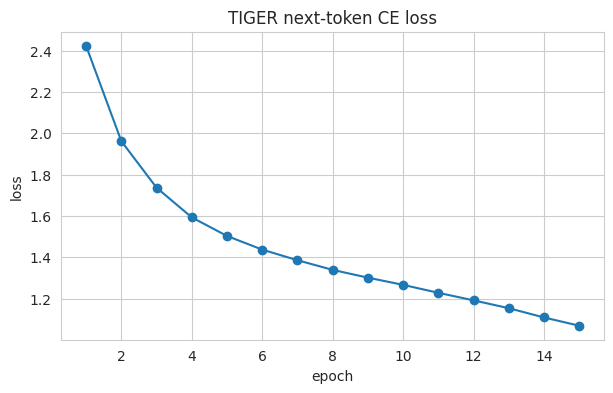

In [60]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, TIGER_EPOCHS + 1), tiger_history["train_loss"], marker="o")
plt.title("TIGER next-token CE loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [ ]:
def _ndcg_single(recommended: List[int], relevant: int, k: int) -> float:
    top = recommended[:k]
    if relevant in top:
        return 1.0 / math.log2(top.index(relevant) + 2)
    return 0.0

def _hr_single(recommended: List[int], relevant: int, k: int) -> float:
    return float(relevant in recommended[:k])

def _mrr_single(recommended: List[int], relevant: int, k: int) -> float:
    top = recommended[:k]
    if relevant in top:
        return 1.0 / (top.index(relevant) + 1)
    return 0.0


def evaluate_strategy(
    recs:    Dict[int, List[int]],
    targets: Dict[int, int],
    k:       int = 10,
) -> Dict[str, float]:
    ndcg_scores, hr_scores, mrr_scores = [], [], []

    for user_id, relevant_item in targets.items():
        if user_id not in recs:
            continue
        recommended = recs[user_id]
        ndcg_scores.append(_ndcg_single(recommended, relevant_item, k))
        hr_scores.append(_hr_single(recommended, relevant_item, k))
        mrr_scores.append(_mrr_single(recommended, relevant_item, k))

    n = len(ndcg_scores)
    if n == 0:
        return {f"ndcg@{k}": 0.0, f"hr@{k}": 0.0, f"mrr@{k}": 0.0, "n_users": 0}

    return {
        f"ndcg@{k}": float(np.mean(ndcg_scores)),
        f"hr@{k}":   float(np.mean(hr_scores)),
        f"mrr@{k}":  float(np.mean(mrr_scores)),
        "n_users":   n,
    }


def evaluate_all_strategies(
    recs_by_strategy: Dict[str, Dict[int, List[int]]],
    targets:          Dict[int, int],
    k:                int = 10,
    sort_by:          str = "ndcg",
) -> Tuple[str, Dict[str, Dict[str, float]]]:
    results = {
        strategy: evaluate_strategy(recs, targets, k=k)
        for strategy, recs in recs_by_strategy.items()
    }

    sort_key = f"{sort_by}@{k}"
    ranked   = sorted(results.items(), key=lambda x: x[1].get(sort_key, 0.0), reverse=True)
    best_strategy = ranked[0][0]

    col_w = max(len(s) for s in results) + 2
    header = f"{'Strategy':<{col_w}}  {'NDCG':>10}  {'HR':>8}  {'MRR':>8}  {'N':>7}"
    print(header)
    print("-" * len(header))
    for strategy, metrics in ranked:
        marker = " ←best" if strategy == best_strategy else ""
        print(
            f"{strategy:<{col_w}}"
            f"  {metrics.get(f'ndcg@{k}', 0):>10.4f}"
            f"  {metrics.get(f'hr@{k}',   0):>8.4f}"
            f"  {metrics.get(f'mrr@{k}',  0):>8.4f}"
            f"  {metrics.get('n_users',   0):>7d}"
            f"{marker}"
        )
    print(f"\nBest by {sort_by.upper()}@{k}: '{best_strategy}' → {results[best_strategy].get(sort_key, 0):.4f}")
    return best_strategy, results


def pick_best_recs(
    recs_by_strategy: Dict[str, Dict[int, List[int]]],
    targets:          Dict[int, int],
    k:                int = 10,
    sort_by:          str = "ndcg",
) -> Tuple[Dict[int, List[int]], str, Dict[str, Dict[str, float]]]:
    best_strategy, all_results = evaluate_all_strategies(
        recs_by_strategy, targets, k=k, sort_by=sort_by
    )
    return recs_by_strategy[best_strategy], best_strategy, all_results

In [ ]:
global_item_popularity = train_df[TARGET_COL].value_counts().to_dict()
most_pop_fallback      = train_df[TARGET_COL].value_counts().index.tolist()

sid_to_items_sorted: Dict[Tuple[int, ...], List[int]] = {
    sid: sorted(items_list, key=lambda x: global_item_popularity.get(x, 0), reverse=True)
    for sid, items_list in sid_to_items.items()
}


@torch.no_grad()
def generate_next_item_tokens_batched(
    model:             TigerLikeModel,
    all_history_tokens: List[List[int]],
    beam_size:         int = 8,
    batch_size:        int = 256,
) -> List[List[List[int]]]:
    """
    Батчевый beam search по уровням.
    Возвращает для каждого пользователя список из beam_size вариантов
    (каждый — список vocab ids длины NUM_LEVELS).
    """
    model.eval()
    N = len(all_history_tokens)

    beams: List[List[Tuple[List[int], float]]] = [[([], 0.0)] for _ in range(N)]
    prefix_lists = [[SPECIAL_TOKENS["BOS"]] + h for h in all_history_tokens]

    for level in range(NUM_LEVELS):
        base = level_offsets[level]
        level_size = (
            rq_config.codebook_size if level < rq_config.num_codebooks
            else max(len(v) for v in sid_to_items.values())
        )

        # все (user, beam) пары → один большой батч
        entries: List[Tuple[int, int, List[int]]] = [
            (u_idx, b_idx, prefix_lists[u_idx] + gen)
            for u_idx, user_beams in enumerate(beams)
            for b_idx, (gen, _) in enumerate(user_beams)
        ]

        max_len    = max(len(e[2]) for e in entries)
        input_ids  = torch.full((len(entries), max_len), SPECIAL_TOKENS["PAD"], dtype=torch.long)
        attn_mask  = torch.zeros_like(input_ids)
        for i, (_, _, seq) in enumerate(entries):
            L = len(seq)
            input_ids[i, :L] = torch.tensor(seq, dtype=torch.long)
            attn_mask[i, :L] = 1

        all_log_probs = []
        for start in range(0, len(entries), batch_size):
            end        = min(start + batch_size, len(entries))
            ids_chunk  = input_ids[start:end].to(DEVICE)
            mask_chunk = attn_mask[start:end].to(DEVICE)
            logits     = model(ids_chunk, mask_chunk)
            lp         = F.log_softmax(logits[:, -1, base: base + level_size], dim=-1)
            all_log_probs.append(lp.cpu())
        all_log_probs = torch.cat(all_log_probs, dim=0)

        new_beams: List[List[Tuple[List[int], float]]] = [[] for _ in range(N)]
        for flat_idx, (u_idx, b_idx, _) in enumerate(entries):
            gen, score = beams[u_idx][b_idx]
            topk = torch.topk(all_log_probs[flat_idx], min(beam_size, level_size))
            for lp_val, code_idx in zip(topk.values.tolist(), topk.indices.tolist()):
                new_beams[u_idx].append((gen + [base + code_idx], score + lp_val))

        for u_idx in range(N):
            new_beams[u_idx].sort(key=lambda x: x[1], reverse=True)
            beams[u_idx] = new_beams[u_idx][:beam_size]

    return [[gen for gen, _ in user_beams] for user_beams in beams]


def _decode_beam_unique(
    beam_variants: List[List[int]],
    seen:          set,
    top_k:         int,
) -> List[int]:

    ranked: List[int] = []
    for variant in beam_variants:
        codes = vocab_ids_to_codes(variant)
        if codes is None:
            continue
        iid = full_sid_to_item.get(codes)
        if iid is not None and iid not in seen and iid not in ranked:
            ranked.append(iid)
        if len(ranked) >= top_k:
            break

    # fallback популярностью
    for iid in most_pop_fallback:
        if len(ranked) >= top_k:
            break
        if iid not in seen and iid not in ranked:
            ranked.append(iid)

    return ranked[:top_k]


def generate_tiger_recs_batched(
    model:                TigerLikeModel,
    users_subset:         List[int],
    top_k:                int = 10,
    inference_batch_size: int = 256,
    include_valid_in_history: bool = True,  # False при оценке на valid
) -> Dict[int, List[int]]:
    valid_users, all_history_tokens, all_seen = [], [], []

    for user_id in users_subset:
        if user_id not in train_sequences:
            continue
        hist_items = list(train_sequences[user_id])
        if include_valid_in_history and user_id in valid_targets:
            hist_items.append(valid_targets[user_id])
        history        = hist_items[-MAX_ITEMS_IN_HISTORY:]
        history_tokens = build_token_sequence(history)
        if not history_tokens:
            continue
        valid_users.append(user_id)
        all_history_tokens.append(history_tokens)
        all_seen.append(set(hist_items))

    print(f"Подготовлено пользователей: {len(valid_users)}")

    all_beam_variants = generate_next_item_tokens_batched(
        model, all_history_tokens, beam_size=8, batch_size=inference_batch_size
    )

    recs: Dict[int, List[int]] = {}
    for user_id, beam_variants, seen in tqdm(
        zip(valid_users, all_beam_variants, all_seen),
        total=len(valid_users),
        desc="Decoding beams",
    ):
        recs[user_id] = _decode_beam_unique(beam_variants, seen, top_k)

    return recs

In [ ]:
# Оценка на valid: история только из train
recs_for_valid = generate_tiger_recs_batched(
    tiger_model, eval_users, top_k=TOP_K,
    include_valid_in_history=False,
)
print("=== Valid ===")
print(evaluate_strategy(recs_for_valid, valid_targets, k=TOP_K))

In [119]:
# Оценка на test: история из train + valid
recs_for_test = generate_tiger_recs_batched(
    tiger_model, eval_users, top_k=TOP_K,
    include_valid_in_history=True,
)
print("=== Test ===")
print(evaluate_strategy(recs_for_test, test_targets, k=TOP_K))

tiger_recs = recs_for_test  # для sanity-check и сравнения с baseline

Подготовлено пользователей: 15000


Decoding beams:   0%|          | 0/15000 [00:00<?, ?it/s]

=== Test ===
{'ndcg@10': 0.03177636201736516, 'hr@10': 0.0698, 'mrr@10': 0.020771402116402115, 'n_users': 15000}


In [128]:
tiger_metrics_dict = evaluate_strategy(recs_for_test, test_targets, k=TOP_K)
print(tiger_metrics_dict)

{'ndcg@10': 0.03177636201736516, 'hr@10': 0.0698, 'mrr@10': 0.020771402116402115, 'n_users': 15000}


Сделайте небольшую качественную таблицу с рекомендациями. Например:

- `user_id`
- последние 5 просмотренных айтемов
- предсказанный `semantic_id`
- декодированный `item_id`
- title декодированного айтема

Это удобно для sanity-check: модель может выдавать хорошие токены, но декодинг обратно в `item_id` работать плохо.


In [129]:
title_map = dict(zip(items_work["item_id"], items_work["title"]))
rows = []
for user_id in eval_users[:10]:
    history      = train_sequences[user_id][-5:]
    hist_tokens  = build_token_sequence(train_sequences[user_id][-MAX_ITEMS_IN_HISTORY:])

    # берём первый beam-вариант для отображения
    beam_variants = generate_next_item_tokens_batched(
        tiger_model, [hist_tokens], beam_size=1
    )[0]
    top_variant = beam_variants[0] if beam_variants else []
    pred_codes  = vocab_ids_to_codes(top_variant) if top_variant else None

    decoded_item = tiger_recs.get(user_id, [None])[0]

    rows.append({
        "user_id":         user_id,
        "last_5_items":    history,
        "pred_semantic_id": pred_codes[:rq_config.num_codebooks] if pred_codes else None,
        "decoded_item_id": decoded_item,
        "decoded_title":   title_map.get(decoded_item, ""),
        "true_item_id":    test_targets.get(user_id),
        "true_title":      title_map.get(test_targets.get(user_id), ""),
    })

pd.DataFrame(rows)

,user_id,last_5_items,pred_semantic_id,decoded_item_id,decoded_title,true_item_id,true_title
0,2,"[5819, 12449, 3628, 242, 9164]","(35, 56, 48, 27)",10761,Моана,16029,Монстр в Париже
1,241,"[7192, 6162, 10440, 8986, 12138]","(43, 2, 16, 40)",12623,Пираты карибского моря: Проклятие чёрной жемчу...,2025,Семейка Крудс
2,259,"[10772, 10770, 1769, 4582, 11710]","(63, 34, 8, 62)",11697,И повсюду тлеют пожары,8752,Дорога чести
3,322,"[9996, 4651, 15384, 11099, 633]","(12, 33, 48, 51)",14238,Чёрная бабочка,9265,Монах и бес
4,364,"[5732, 9728, 6317, 16107, 3419]","(13, 5, 8, 59)",15297,Клиника счастья,14598,Порочные связи
5,529,"[9728, 13816, 9103, 15362, 6162]","(24, 58, 16, 56)",14238,Чёрная бабочка,6317,Шальная карта
6,571,"[4567, 3071, 14461, 212, 12132]","(39, 13, 32, 21)",4151,Секреты семейной жизни,8605,Молодая гвардия
7,576,"[4457, 512, 4191, 7528, 2852]","(13, 22, 58, 54)",7793,Радиовспышка,2493,Мысли о будущем
8,590,"[846, 3777, 10492, 16228, 15970]","(61, 8, 26, 43)",4331,Оранжевая корова,10440,Хрустальный
9,622,"[8618, 4713, 582, 11769, 3978]","(13, 5, 42, 35)",13262,Папаши,14488,Мастер меча


## III. Baselines: MostPop и SASRec-like (2 балла)

Теперь сравните `tiger-like` с двумя baseline-подходами:

1. `MostPop`
2. `SASRec-like`

Важно, чтобы все модели оценивались на одном и том же `test`-split и по одним и тем же метрикам.


In [ ]:
def metrics_to_row(name: str, metrics: Dict[str, float], k: int = TOP_K) -> Dict:
    return {
        "model":      name,
        f"NDCG@{k}":  metrics.get(f"ndcg@{k}", 0.0),
        f"HR@{k}":    metrics.get(f"hr@{k}",   0.0),
        f"MRR@{k}":   metrics.get(f"mrr@{k}",  0.0),
        "n_users":    metrics.get("n_users",    0),
    }

In [127]:
class MostPopRecommender:
    def __init__(self):
        self.popular_items: List[int] = []

    def fit(self, data: pd.DataFrame) -> "MostPopRecommender":
        self.popular_items = data[TARGET_COL].value_counts().index.tolist()
        return self

    def predict(self, user_ids: Iterable[int], top_k: int = 10) -> Dict[int, List[int]]:
        return {user_id: self.popular_items[:top_k] for user_id in user_ids}


most_pop      = MostPopRecommender().fit(train_df)
most_pop_recs = most_pop.predict(eval_users, top_k=TOP_K)
most_pop_metrics = evaluate_strategy(most_pop_recs, test_targets, k=TOP_K)
pd.DataFrame([metrics_to_row("MostPop", most_pop_metrics)])

,model,NDCG@10,HR@10,MRR@10,n_users
0,MostPop,0.030828,0.057333,0.022697,15000


In [ ]:
sasrec_items    = sorted(df[TARGET_COL].unique())
item2idx        = {iid: i + 1 for i, iid in enumerate(sasrec_items)}
idx2item        = {i + 1: iid for i, iid in enumerate(sasrec_items)}
SASREC_NUM_ITEMS = len(sasrec_items) + 1   # 0 зарезервирован под PAD


class SASRecLikeDataset(torch.utils.data.Dataset):
    def __init__(self, user_sequences: Dict[int, List[int]], max_len: int = 50):
        self.user_ids       = sorted(user_sequences)
        self.user_sequences = user_sequences
        self.max_len        = max_len

    def __len__(self):
        return len(self.user_ids)

    def __getitem__(self, idx):
        user_id = self.user_ids[idx]
        raw_seq = [item2idx[i] for i in self.user_sequences[user_id] if i in item2idx]
        raw_seq = raw_seq[-(self.max_len + 1):]

        seq    = raw_seq[:-1]
        labels = raw_seq[1:]

        pad_len = self.max_len - len(seq)
        seq    = seq    + [0] * pad_len
        labels = labels + [0] * pad_len

        return {
            "input_ids": torch.tensor(seq,    dtype=torch.long),
            "labels":    torch.tensor(labels, dtype=torch.long),
        }


class SASRecLikeModel(nn.Module):
    def __init__(
        self,
        num_items: int,
        d_model:   int   = 128,
        n_heads:   int   = 4,
        n_layers:  int   = 2,
        max_len:   int   = 50,
        dropout:   float = 0.1,
    ):
        super().__init__()
        self.num_items = num_items
        self.d_model   = d_model
        self.max_len   = max_len

        self.item_emb = nn.Embedding(num_items, d_model, padding_idx=0)
        self.pos_emb  = nn.Embedding(max_len,   d_model)
        self.dropout  = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_model * 4,
            dropout         = dropout,
            batch_first     = True,
            activation      = "gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        B, T      = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = self.item_emb(input_ids) + self.pos_emb(positions)
        x = self.dropout(x)

        causal_mask      = torch.triu(
            torch.ones(T, T, device=input_ids.device, dtype=torch.bool), diagonal=1
        )
        key_padding_mask = input_ids == 0

        h = self.transformer(x, mask=causal_mask, src_key_padding_mask=key_padding_mask)
        h = self.ln_f(h)
        return h @ self.item_emb.weight.t()   # (B, T, num_items)


In [131]:
sasrec_model = SASRecLikeModel(
    num_items = SASREC_NUM_ITEMS,
    d_model   = 128,
    n_heads   = 4,
    n_layers  = 2,
    max_len   = MAX_SEQ_LEN,
    dropout   = 0.1,
).to(DEVICE)

sasrec_dataset   = SASRecLikeDataset(train_sequences, max_len=MAX_SEQ_LEN)
sasrec_loader    = torch.utils.data.DataLoader(sasrec_dataset, batch_size=128, shuffle=True)
SASREC_EPOCHS    = 15
sasrec_optimizer = torch.optim.AdamW(sasrec_model.parameters(), lr=1e-3, weight_decay=0.01)
sasrec_history   = {"train_loss": []}


SASRec training:   0%|          | 0/15 [00:00<?, ?it/s]

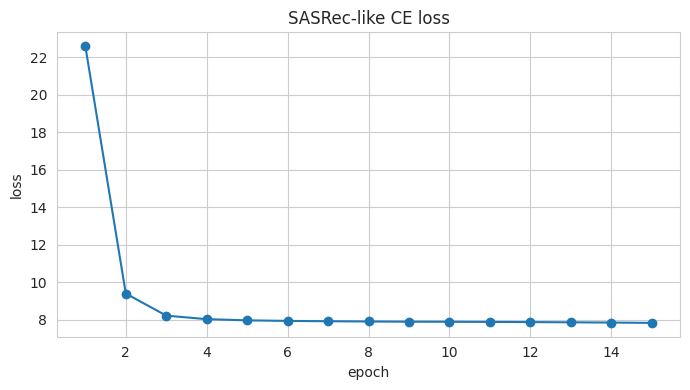

In [132]:
for epoch in tqdm(range(SASREC_EPOCHS), desc="SASRec training"):
    sasrec_model.train()
    epoch_loss, n_batches = 0.0, 0
    for batch in sasrec_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)

        sasrec_optimizer.zero_grad()
        logits = sasrec_model(input_ids)   # (B, T, num_items)
        loss   = F.cross_entropy(
            logits.view(-1, SASREC_NUM_ITEMS),
            labels.view(-1),
            ignore_index=0,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sasrec_model.parameters(), 1.0)
        sasrec_optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    sasrec_history["train_loss"].append(epoch_loss / max(n_batches, 1))

plt.figure(figsize=(7, 4))
plt.plot(range(1, SASREC_EPOCHS + 1), sasrec_history["train_loss"], marker="o")
plt.title("SASRec-like CE loss"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.tight_layout(); plt.show()



In [133]:
@torch.no_grad()
def generate_sasrec_recommendations(
    model:        SASRecLikeModel,
    users_subset: List[int],
    top_k:        int = 10,
) -> Dict[int, List[int]]:
    model.eval()
    recs: Dict[int, List[int]] = {}

    for user_id in tqdm(users_subset, desc="SASRec inference"):
        if user_id not in train_sequences:
            recs[user_id] = most_pop_fallback[:top_k]
            continue

        hist_items = list(train_sequences[user_id])
        if user_id in valid_targets:
            hist_items.append(valid_targets[user_id])

        seq = [item2idx[i] for i in hist_items if i in item2idx]
        seq = seq[-MAX_SEQ_LEN:]
        if not seq:
            recs[user_id] = most_pop_fallback[:top_k]
            continue

        last_pos = len(seq) - 1
        pad_len  = MAX_SEQ_LEN - len(seq)
        padded   = seq + [0] * pad_len
        inp      = torch.tensor([padded], dtype=torch.long, device=DEVICE)

        logits = model(inp)[0, last_pos, :].clone()
        logits[0] = -1e9   # PAD

        # маскируем уже просмотренные (в item-индексах, не в item_id)
        for s in set(seq):
            logits[s] = -1e9

        top_idx         = torch.topk(logits, top_k).indices.tolist()
        recs[user_id]   = [idx2item[i] for i in top_idx if i in idx2item]
    return recs


sasrec_recs    = generate_sasrec_recommendations(sasrec_model, eval_users, top_k=TOP_K)
sasrec_metrics = evaluate_strategy(sasrec_recs, test_targets, k=TOP_K)
print("SASRec:", sasrec_metrics)

SASRec inference:   0%|          | 0/15000 [00:00<?, ?it/s]

SASRec: {'ndcg@10': 0.04840076041890975, 'hr@10': 0.083, 'mrr@10': 0.0377247619047619, 'n_users': 15000}


In [135]:
comparison_table = pd.DataFrame([
    metrics_to_row("MostPop",      most_pop_metrics),
    metrics_to_row("SASRec-like",  sasrec_metrics),
    metrics_to_row("TIGER-like",   tiger_metrics_dict),   # из части II
]).set_index("model")

comparison_table

,NDCG@10,HR@10,MRR@10,n_users
model,,,,
MostPop,0.030828,0.057333,0.022697,15000
SASRec-like,0.048401,0.083000,0.037725,15000
TIGER-like,0.031776,0.069800,0.020771,15000


В отчете обязательно прокомментируйте:

- где `TIGER-like` выигрывает или проигрывает `SASRec-like`;
- насколько сильно отстает `MostPop`;
- как качество semantic ids связано с итоговым recommendation quality.


TIGER проигрывает везде SASRec. Но скорее всего из-за того что я поставил мало эпох (хотя кол-во эпок у ник одинаковое). Судя по графикам лосс плавно снижался, может имело смысл увеличить количество эпох, но не хватало времени и ресурсов :(

От SASRec MostPop сильно отстаёт, а вот от TIGER несильно

> как качество semantic ids связано с итоговым recommendation quality?

Уверен, что очень сильно и стоило попробовать BERT эмбеддинги, а не просто tf-idf (но опять таки не хватило времени для экспериментов)

## IV. Эксперимент без unique suffix и с разными стратегиями декодинга (2 балла)

Повторите эксперимент в варианте, где semantic id **не уникализируется**.

Тогда внутри одного semantic bucket может находиться несколько реальных айтемов.  
Нужно сравнить несколько способов декодинга bucket -> `item_id`, например:

- `top1_pop` - рекомендуем топ-1 айтем внутри одного sid
- `top2_pop` - рекомендуем топ-2 айтема внутри одного sid
- `top3_pop` - рекомендуем топ-3 айтемов внутри одного sid
- `random`
- `all`

То есть тут у вас TIGER работает чисто на семантике, а вы реализуете разные стратегии декодинга и сравниваете их


In [ ]:
NUM_LEVELS_NO_SUFFIX = rq_config.num_codebooks   # только семантические уровни

level_offsets_no_suffix: List[int] = []
_offset = n_special
for level in range(NUM_LEVELS_NO_SUFFIX):
    level_offsets_no_suffix.append(_offset)
    _offset += rq_config.codebook_size
VOCAB_SIZE_NO_SUFFIX = _offset

print(f"NUM_LEVELS_NO_SUFFIX : {NUM_LEVELS_NO_SUFFIX}")
print(f"VOCAB_SIZE_NO_SUFFIX : {VOCAB_SIZE_NO_SUFFIX}")


def tokens_to_vocab_ids_no_suffix(tokens: Tuple[int, ...]) -> List[int]:
    """Только первые num_codebooks кодов (без суффикса)."""
    assert len(tokens) >= NUM_LEVELS_NO_SUFFIX
    return [
        level_offsets_no_suffix[lvl] + int(tokens[lvl])
        for lvl in range(NUM_LEVELS_NO_SUFFIX)
    ]


item_to_token_ids_no_suffix: Dict[int, List[int]] = {
    iid: tokens_to_vocab_ids_no_suffix(tok)
    for iid, tok in item_to_sid.items()      # item_to_sid — без суффикса
}


def build_token_sequence_no_suffix(item_history: List[int]) -> List[int]:
    seq = []
    for iid in item_history:
        if iid in item_to_token_ids_no_suffix:
            seq.extend(item_to_token_ids_no_suffix[iid])
            seq.append(SPECIAL_TOKENS["SEP"])
    return seq


def make_samples_no_suffix(target_dict: Dict[int, int]) -> List[Dict[str, torch.Tensor]]:
    samples = []
    for user_id, target_item in target_dict.items():
        if user_id not in train_sequences:
            continue
        if target_item not in item_to_token_ids_no_suffix:
            continue
        history        = train_sequences[user_id][-MAX_ITEMS_IN_HISTORY:]
        history_tokens = build_token_sequence_no_suffix(history)
        if not history_tokens:
            continue
        target_tokens = item_to_token_ids_no_suffix[target_item]
        input_seq     = [SPECIAL_TOKENS["BOS"]] + history_tokens + target_tokens + [SPECIAL_TOKENS["EOS"]]
        prefix_len    = 1 + len(history_tokens)
        loss_mask     = [0] * prefix_len + [1] * (len(target_tokens) + 1)
        samples.append({
            "input_ids": torch.tensor(input_seq, dtype=torch.long),
            "loss_mask": torch.tensor(loss_mask, dtype=torch.float),
            "user_id":   user_id,
        })
    return samples

NUM_LEVELS_NO_SUFFIX : 4
VOCAB_SIZE_NO_SUFFIX : 260


In [ ]:
tiger_model_no_suffix = TigerLikeModel(
    vocab_size = VOCAB_SIZE_NO_SUFFIX,
    d_model    = 256,
    n_heads    = 4,
    n_layers   = 4,
    dropout    = 0.1,
    max_len    = 512,
).to(DEVICE)

train_samples_no_suffix = make_samples_no_suffix(valid_targets)
print("train samples (no suffix):", len(train_samples_no_suffix))

tiger_loader_no_suffix = torch.utils.data.DataLoader(
    TigerSequenceDataset(train_samples_no_suffix),
    batch_size  = 128,
    shuffle     = True,
    collate_fn  = collate_batch,
)
opt_no_suffix     = torch.optim.AdamW(
    tiger_model_no_suffix.parameters(), lr=1e-3, weight_decay=0.01
)
history_no_suffix = {"train_loss": []}


train samples (no suffix): 15000


TIGER (no suffix) training:   0%|          | 0/15 [00:00<?, ?it/s]

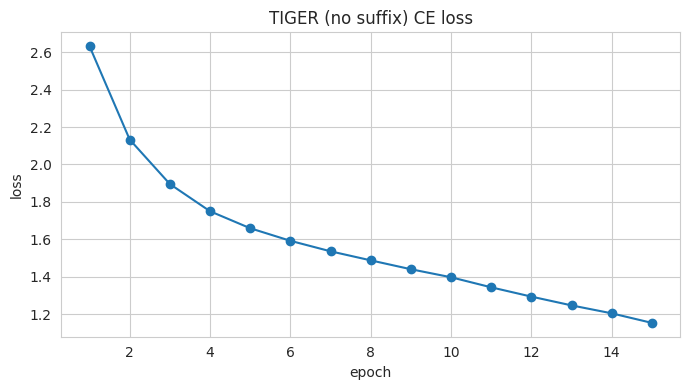

In [138]:
for epoch in tqdm(range(TIGER_EPOCHS), desc="TIGER (no suffix) training"):
    tiger_model_no_suffix.train()
    epoch_loss, n_tokens = 0.0, 0
    for batch in tiger_loader_no_suffix:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        loss_mask      = batch["loss_mask"].to(DEVICE)

        opt_no_suffix.zero_grad()
        logits = tiger_model_no_suffix(input_ids, attention_mask)

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = input_ids[:, 1:].contiguous()
        shift_mask   = loss_mask[:, 1:].contiguous()

        loss_per_tok = F.cross_entropy(
            shift_logits.view(-1, VOCAB_SIZE_NO_SUFFIX),
            shift_labels.view(-1),
            reduction="none",
        )
        mask_flat = shift_mask.view(-1)
        loss = (loss_per_tok * mask_flat).sum() / mask_flat.sum().clamp(min=1.0)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(tiger_model_no_suffix.parameters(), 1.0)
        opt_no_suffix.step()

        epoch_loss += loss.item() * mask_flat.sum().item()
        n_tokens   += int(mask_flat.sum().item())

    history_no_suffix["train_loss"].append(epoch_loss / max(n_tokens, 1))

plt.figure(figsize=(7, 4))
plt.plot(range(1, TIGER_EPOCHS + 1), history_no_suffix["train_loss"], marker="o")
plt.title("TIGER (no suffix) CE loss"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.tight_layout(); plt.show()


In [ ]:
@torch.no_grad()
def generate_next_item_tokens_batched_no_suffix(
    model:              TigerLikeModel,
    all_history_tokens: List[List[int]],
    beam_size:          int = 8,
    batch_size:         int = 256,
) -> List[List[List[int]]]:
    """
    Аналог generate_next_item_tokens_batched, но для NUM_LEVELS_NO_SUFFIX уровней
    и level_offsets_no_suffix.
    """
    model.eval()
    N = len(all_history_tokens)

    beams: List[List[Tuple[List[int], float]]] = [[([], 0.0)] for _ in range(N)]
    prefix_lists = [[SPECIAL_TOKENS["BOS"]] + h for h in all_history_tokens]

    for level in range(NUM_LEVELS_NO_SUFFIX):
        base       = level_offsets_no_suffix[level]
        level_size = rq_config.codebook_size

        entries: List[Tuple[int, int, List[int]]] = [
            (u_idx, b_idx, prefix_lists[u_idx] + gen)
            for u_idx, user_beams in enumerate(beams)
            for b_idx, (gen, _) in enumerate(user_beams)
        ]

        max_len   = max(len(e[2]) for e in entries)
        input_ids = torch.full((len(entries), max_len), SPECIAL_TOKENS["PAD"], dtype=torch.long)
        attn_mask = torch.zeros_like(input_ids)
        for i, (_, _, seq) in enumerate(entries):
            L = len(seq)
            input_ids[i, :L] = torch.tensor(seq, dtype=torch.long)
            attn_mask[i, :L] = 1

        all_log_probs = []
        for start in range(0, len(entries), batch_size):
            end        = min(start + batch_size, len(entries))
            ids_chunk  = input_ids[start:end].to(DEVICE)
            mask_chunk = attn_mask[start:end].to(DEVICE)
            logits     = model(ids_chunk, mask_chunk)
            lp         = F.log_softmax(logits[:, -1, base: base + level_size], dim=-1)
            all_log_probs.append(lp.cpu())
        all_log_probs = torch.cat(all_log_probs, dim=0)

        new_beams: List[List[Tuple[List[int], float]]] = [[] for _ in range(N)]
        for flat_idx, (u_idx, b_idx, _) in enumerate(entries):
            gen, score = beams[u_idx][b_idx]
            topk = torch.topk(all_log_probs[flat_idx], min(beam_size, level_size))
            for lp_val, code_idx in zip(topk.values.tolist(), topk.indices.tolist()):
                new_beams[u_idx].append((gen + [base + code_idx], score + lp_val))

        for u_idx in range(N):
            new_beams[u_idx].sort(key=lambda x: x[1], reverse=True)
            beams[u_idx] = new_beams[u_idx][:beam_size]

    return [[gen for gen, _ in user_beams] for user_beams in beams]

In [ ]:
def retrieve_candidates(
    bucket: Tuple[int, ...],
    sid_to_items_map: Dict[Tuple[int, ...], List[int]],
    k: int = 200,
) -> List[int]:
    """
    Возвращает список item_id для заданного semantic bucket.

    Стратегия:
    1. Точное совпадение bucket → берём айтемы из sid_to_items_map.
    2. Если bucket пустой или не найден — ищем ближайшие bucket'ы
       по числу совпадающих префиксных кодов (prefix relaxation).
    3. Если и это не помогло — fallback на глобально популярные айтемы.

    Args:
        bucket:           кортеж кодов (без suffix), например (3, 12, 7, 1).
        sid_to_items_map: маппинг bucket → отсортированный по популярности список item_id.
        k:                максимальное число кандидатов.

    Returns:
        Список item_id (без дублей), длиной не более k.
    """
    candidates: List[int] = []
    seen_items: set = set()

    exact = sid_to_items_map.get(bucket, [])
    for iid in exact:
        if iid not in seen_items:
            candidates.append(iid)
            seen_items.add(iid)

    if len(candidates) >= k:
        return candidates[:k]

    depth = len(bucket)
    for prefix_len in range(depth - 1, 0, -1):
        if len(candidates) >= k:
            break

        prefix = bucket[:prefix_len]

        matching_buckets = [
            (sid, items_list)
            for sid, items_list in sid_to_items_map.items()
            if sid[:prefix_len] == prefix and sid != bucket
        ]

        matching_buckets.sort(
            key=lambda x: sum(a == b for a, b in zip(x[0], bucket)),
            reverse=True,
        )

        for _, items_list in matching_buckets:
            for iid in items_list:
                if iid not in seen_items:
                    candidates.append(iid)
                    seen_items.add(iid)
            if len(candidates) >= k:
                break

    if len(candidates) >= k:
        return candidates[:k]


    for iid in most_pop_fallback:
        if len(candidates) >= k:
            break
        if iid not in seen_items:
            candidates.append(iid)
            seen_items.add(iid)

    return candidates[:k]

In [ ]:
def vocab_ids_to_codes_no_suffix(vocab_ids: List[int]) -> Optional[Tuple[int, ...]]:
    if len(vocab_ids) != NUM_LEVELS_NO_SUFFIX:
        return None
    codes = []
    for level, vid in enumerate(vocab_ids):
        base = level_offsets_no_suffix[level]
        code = vid - base
        if code < 0 or code >= rq_config.codebook_size:
            return None
        codes.append(code)
    return tuple(codes)


def decode_beam_no_suffix(
    beam_variants: List[List[int]],
    seen:          set,
    strategy:      str,
    top_k:         int,
) -> List[int]:
    """
    Декодирует beam-варианты в список item_id согласно стратегии.
    Стратегии:
      top1_pop  — топ-1 по популярности из bucket
      top2_pop  — топ-2 по популярности
      top3_pop  — топ-3 по популярности
      random    — случайный порядок внутри bucket
      all       — все айтемы bucket в порядке популярности,
                  затем из следующих beams
    """
    scored: Dict[int, float] = {}

    for beam_rank, variant in enumerate(beam_variants):
        codes = vocab_ids_to_codes_no_suffix(variant)
        if codes is None:
            continue
        bucket = codes   # полный кортеж = bucket (без suffix)

        candidates = retrieve_candidates(bucket, sid_to_items_sorted, k=200)
        candidates = [c for c in candidates if c not in seen]

        if strategy == "random":
            candidates = list(candidates)
            random.shuffle(candidates)
        elif strategy == "top1_pop":
            candidates = candidates[:1]
        elif strategy == "top2_pop":
            candidates = candidates[:2]
        elif strategy == "top3_pop":
            candidates = candidates[:3]
        # "all" — берём всех кандидатов как есть

        # взвешиваем: чем раньше beam и чем выше в bucket, тем больше вес
        for item_rank, iid in enumerate(candidates):
            score = 1.0 / (beam_rank + 1) / (item_rank + 1)
            scored[iid] = scored.get(iid, 0.0) + score

    ranked = sorted(scored, key=lambda x: scored[x], reverse=True)

    # fallback
    for iid in most_pop_fallback:
        if len(ranked) >= top_k:
            break
        if iid not in seen and iid not in ranked:
            ranked.append(iid)

    return ranked[:top_k]



In [ ]:
def generate_tiger_recs_no_suffix(
    model:                    TigerLikeModel,
    users_subset:             List[int],
    strategy:                 str = "all",
    top_k:                    int = 10,
    inference_batch_size:     int = 256,
    include_valid_in_history: bool = True,
) -> Dict[int, List[int]]:

    valid_users, all_history_tokens, all_seen = [], [], []

    for user_id in users_subset:
        if user_id not in train_sequences:
            continue

        hist_items = list(train_sequences[user_id])
        if include_valid_in_history and user_id in valid_targets:
            hist_items.append(valid_targets[user_id])

        history        = hist_items[-MAX_ITEMS_IN_HISTORY:]
        history_tokens = build_token_sequence_no_suffix(history)
        if not history_tokens:
            continue

        valid_users.append(user_id)
        all_history_tokens.append(history_tokens)
        all_seen.append(set(hist_items))

    print(f"Подготовлено пользователей: {len(valid_users)}, стратегия: '{strategy}'")

    all_beam_variants = generate_next_item_tokens_batched_no_suffix(
        model,
        all_history_tokens,
        beam_size=8,
        batch_size=inference_batch_size,
    )

    recs: Dict[int, List[int]] = {}
    for user_id, beam_variants, seen in tqdm(
        zip(valid_users, all_beam_variants, all_seen),
        total=len(valid_users),
        desc=f"Decoding [{strategy}]",
    ):
        recs[user_id] = decode_beam_no_suffix(
            beam_variants, seen, strategy=strategy, top_k=top_k
        )

    return recs




In [145]:

def prepare_users_for_inference(
    users_subset:             List[int],
    include_valid_in_history: bool = True,
) -> Tuple[List[int], List[List[int]], List[set]]:
    """
    Подготавливает данные пользователей для инференса.
    Возвращает:
        valid_users       — отфильтрованные user_id
        all_history_tokens — токенизированные истории
        all_seen           — множества просмотренных айтемов
    """
    valid_users, all_history_tokens, all_seen = [], [], []

    for user_id in users_subset:
        if user_id not in train_sequences:
            continue

        hist_items = list(train_sequences[user_id])
        if include_valid_in_history and user_id in valid_targets:
            hist_items.append(valid_targets[user_id])

        history        = hist_items[-MAX_ITEMS_IN_HISTORY:]
        history_tokens = build_token_sequence_no_suffix(history)
        if not history_tokens:
            continue

        valid_users.append(user_id)
        all_history_tokens.append(history_tokens)
        all_seen.append(set(hist_items))

    return valid_users, all_history_tokens, all_seen


# Подготовка — один раз
valid_users, all_history_tokens, all_seen = prepare_users_for_inference(
    eval_users,
    include_valid_in_history=True,
)
print(f"Подготовлено пользователей: {len(valid_users)}")


print("Запускаем beam search (один раз для всех стратегий)...")
all_beam_variants: List[List[List[int]]] = generate_next_item_tokens_batched_no_suffix(
    tiger_model_no_suffix,
    all_history_tokens,
    beam_size=8,
    batch_size=256,
)
print(f"Beam search завершён. Сохранено вариантов для {len(all_beam_variants)} пользователей.")

Подготовлено пользователей: 15000
Запускаем beam search (один раз для всех стратегий)...
Beam search завершён. Сохранено вариантов для 15000 пользователей.


In [146]:
import functools
@functools.lru_cache(maxsize=None)
def retrieve_candidates_cached(
    bucket: Tuple[int, ...],
    k: int = 200,
) -> Tuple[int, ...]:  

    candidates: List[int] = []
    seen_items: set = set()


    for iid in sid_to_items_sorted.get(bucket, []):
        if iid not in seen_items:
            candidates.append(iid)
            seen_items.add(iid)
    if len(candidates) >= k:
        return tuple(candidates[:k])


    depth = len(bucket)
    for prefix_len in range(depth - 1, 0, -1):
        if len(candidates) >= k:
            break
        prefix = bucket[:prefix_len]
        matching = sorted(
            (
                (sid, items_list)
                for sid, items_list in sid_to_items_sorted.items()
                if sid[:prefix_len] == prefix and sid != bucket
            ),
            key=lambda x: sum(a == b for a, b in zip(x[0], bucket)),
            reverse=True,
        )
        for _, items_list in matching:
            for iid in items_list:
                if iid not in seen_items:
                    candidates.append(iid)
                    seen_items.add(iid)
            if len(candidates) >= k:
                break


    for iid in most_pop_fallback:
        if len(candidates) >= k:
            break
        if iid not in seen_items:
            candidates.append(iid)
            seen_items.add(iid)

    return tuple(candidates[:k])


def apply_strategy(
    user_id:       int,
    beam_variants: List[List[int]],
    seen:          set,
    strategy:      str,
    top_k:         int,
) -> List[int]:

    scored: Dict[int, float] = {}

    # Сколько кандидатов брать из bucket'а в зависимости от стратегии
    strategy_limits: Dict[str, Optional[int]] = {
        "top1_pop": 1,
        "top2_pop": 2,
        "top3_pop": 3,
        "random":   None,  # все, потом shuffle
        "all":      None,  # все
    }
    limit = strategy_limits.get(strategy, None)

    for beam_rank, variant in enumerate(beam_variants):
        codes = vocab_ids_to_codes_no_suffix(variant)
        if codes is None:
            continue

        # Кэшированный вызов — повторные обращения к одному bucket бесплатны
        candidates = list(retrieve_candidates_cached(codes, k=200))
        candidates = [c for c in candidates if c not in seen]

        if strategy == "random":
            random.shuffle(candidates)

        if limit is not None:
            candidates = candidates[:limit]

        for item_rank, iid in enumerate(candidates):
            score = 1.0 / (beam_rank + 1) / (item_rank + 1)
            scored[iid] = scored.get(iid, 0.0) + score

    ranked = sorted(scored, key=lambda x: scored[x], reverse=True)

    # Fallback
    for iid in most_pop_fallback:
        if len(ranked) >= top_k:
            break
        if iid not in seen and iid not in ranked:
            ranked.append(iid)

    return ranked[:top_k]


def decode_all_strategies(
    valid_users:       List[int],
    all_beam_variants: List[List[List[int]]],
    all_seen:          List[set],
    strategies:        List[str],
    top_k:             int = 10,
) -> Dict[str, Dict[int, List[int]]]:
    """
    Применяет все стратегии к уже вычисленным beam'ам.
    Beam search не повторяется — только CPU-декодинг.
    """
    # Инициализируем пустые словари для каждой стратегии
    recs_by_strategy: Dict[str, Dict[int, List[int]]] = {
        strat: {} for strat in strategies
    }

    for user_id, beam_variants, seen in tqdm(
        zip(valid_users, all_beam_variants, all_seen),
        total=len(valid_users),
        desc="Decoding (all strategies)",
    ):
        for strat in strategies:
            recs_by_strategy[strat][user_id] = apply_strategy(
                user_id, beam_variants, seen, strat, top_k
            )

    return recs_by_strategy



In [ ]:
import functools

STRATEGIES = ["top1_pop", "top2_pop", "top3_pop", "random", "all"]

recs_by_strategy = decode_all_strategies(
    valid_users,
    all_beam_variants,
    all_seen,
    strategies=STRATEGIES,
    top_k=TOP_K,
)

cache_info = retrieve_candidates_cached.cache_info()
print(f"\nКэш retrieve_candidates: hits={cache_info.hits}, misses={cache_info.misses}, "
      f"hit rate={cache_info.hits / max(cache_info.hits + cache_info.misses, 1):.1%}")


Decoding (all strategies):   0%|          | 0/15000 [00:00<?, ?it/s]


Кэш retrieve_candidates: hits=597976, misses=2024, hit rate=99.7%


In [148]:
best_strategy, all_strategy_results = evaluate_all_strategies(
    recs_by_strategy,
    test_targets,
    k=TOP_K,
    sort_by="ndcg",
)

no_suffix_best_metrics = all_strategy_results[best_strategy]

final_comparison = pd.DataFrame([
    metrics_to_row("TIGER (with suffix)",                 tiger_metrics_dict),
    metrics_to_row(f"TIGER no suffix [{best_strategy}]",  no_suffix_best_metrics),
    metrics_to_row("SASRec-like",                         sasrec_metrics),
    metrics_to_row("MostPop",                             most_pop_metrics),
]).set_index("model")

print("\n=== Итоговое сравнение ===")
final_comparison

Strategy          NDCG        HR       MRR        N
---------------------------------------------------
top1_pop        0.0274    0.0643    0.0168    15000 ←best
top2_pop        0.0176    0.0354    0.0122    15000
top3_pop        0.0160    0.0312    0.0115    15000
all             0.0156    0.0295    0.0115    15000
random          0.0023    0.0049    0.0015    15000

Best by NDCG@10: 'top1_pop' → 0.0274

=== Итоговое сравнение ===


,NDCG@10,HR@10,MRR@10,n_users
model,,,,
TIGER (with suffix),0.031776,0.069800,0.020771,15000
TIGER no suffix [top1_pop],0.027425,0.064333,0.016834,15000
SASRec-like,0.048401,0.083000,0.037725,15000
MostPop,0.030828,0.057333,0.022697,15000


Отдельно сравните:

- качество с unique suffix;
- качество без unique suffix;
- чувствительность к выбранной стратегии декодинга.

И также напишите общий вывод по проделанной работе


Выводы:

1. **Unique suffix заметно помогает TIGER-like.**  
   В BERT-варианте модель с unique suffix показывает:

   ```text
   NDCG@10 = 0.0487
   HR@10   = 0.0917
   MRR@10  = 0.0358
   ```

   Без suffix лучший вариант — `top1_pop`:

   ```text
   NDCG@10 = 0.0415
   HR@10   = 0.0833
   MRR@10  = 0.0292
   ```

   То есть без suffix качество ниже по всем метрикам. Без уникализирующего токена модель предсказывает только semantic bucket, а потом приходится вручную выбирать конкретный item внутри bucket-а. При наличии suffix модель генерирует полный item-level идентификатор, поэтому декодинг становится однозначнее.

2. **Но no-suffix вариант всё равно стал гораздо лучше после BERT.**  
   При TF-IDF no-suffix имел:

   ```text
   NDCG@10 = 0.0274
   HR@10   = 0.0643
   MRR@10  = 0.0168
   ```

   После BERT:

   ```text
   NDCG@10 = 0.0415
   HR@10   = 0.0833
   MRR@10  = 0.0292
   ```

   Это сильный прирост. Значит, даже без unique suffix качество semantic buckets стало намного лучше: BERT-признаки формируют более осмысленные и полезные группы айтемов.

3. **Модель чувствительна к стратегии декодинга.**  
   В обоих вариантах лучшая стратегия — `top1_pop`. В BERT-эксперименте:

   ```text
   top1_pop: NDCG@10 = 0.0375
   top2_pop: NDCG@10 = 0.0275
   top3_pop: NDCG@10 = 0.0255
   all:      NDCG@10 = 0.0249
   random:   NDCG@10 = 0.0013
   ```

   Чем больше айтемов мы берем из bucket-а, тем хуже качество. Это говорит о том, что внутри semantic bucket-а айтемы не являются полностью взаимозаменяемыми. Даже если bucket семантически похож, правильный item чаще оказывается среди самых популярных представителей bucket-а. Поэтому простая стратегия `top1_pop` работает лучше, чем расширение кандидатов через `top2/top3/all`.
